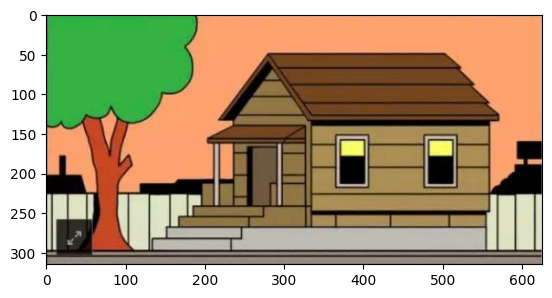

In [1]:
# Khai báo thư viện 
import numpy as np
import cv2
from matplotlib import pyplot as plt
img = cv2.imread('example.jpg')

plt.imshow(img[:,:,::-1]) 

## 2. Sử dụng Harris Corner Detection tìm các keypoint trong ảnh

In [2]:
import numpy as np
import cv2 as cv
filename = 'example.jpg'
img = cv.imread(filename)
gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
gray = np.float32(gray)
dst = cv.cornerHarris(gray,2,3,0.04)
#result is dilated for marking the corners, not important
dst = cv.dilate(dst,None)
# Threshold for an optimal value, it may vary depending on the image.
img[dst>0.01*dst.max()]=[0,0,255]
cv.imshow('dst',img)
if cv.waitKey(0) & 0xff == 27:
    cv.destroyAllWindows()

## Câu 3 - Band-pass filtering by Difference of Gaussians

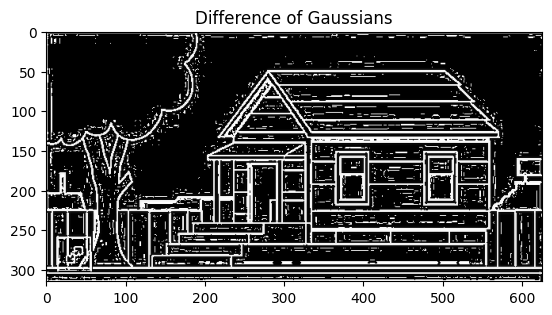

In [3]:
#3. Sử dụng Band-pass filtering by Difference of Gaussians
img = cv2.imread('example.jpg',0)

g1 = cv2.GaussianBlur(img,(5,5),1)
g2 = cv2.GaussianBlur(img,(5,5),2)

dog = g1 - g2

plt.imshow(dog,cmap='gray')
plt.title("Difference of Gaussians")
plt.show()

## 4. Kiểm tra ảnh qua Automatic Scale Selection

In [4]:
#4. Kiểm tra ảnh qua Automatic Scale Selection
img = cv2.imread('example.jpg',0)

sigmas = [1,2,4,8]

responses = []

for s in sigmas:
    blur = cv2.GaussianBlur(img,(0,0),s)
    lap = cv2.Laplacian(blur,cv2.CV_64F)
    responses.append(np.abs(lap).mean())

best_scale = sigmas[np.argmax(responses)]

print("Best scale:", best_scale)

Best scale: 1


## 5. Kiểm tra ảnh qua Scale Invariant Detection

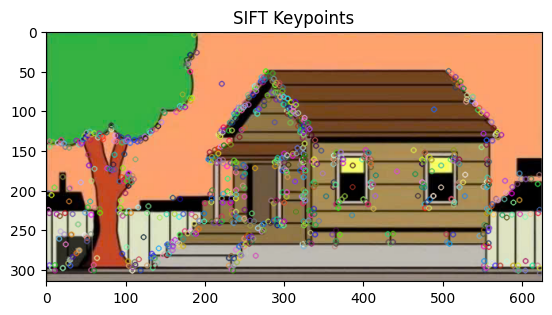

In [5]:
#5. Kiểm tra ảnh qua Scale Invariant Detection
img = cv2.imread('example.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp,des = sift.detectAndCompute(gray,None)

img_kp = cv2.drawKeypoints(img,kp,None)

plt.imshow(img_kp[:,:,::-1])
plt.title("SIFT Keypoints")
plt.show()

## 6. Kiểm tra ảnh qua Scale-space blob detector

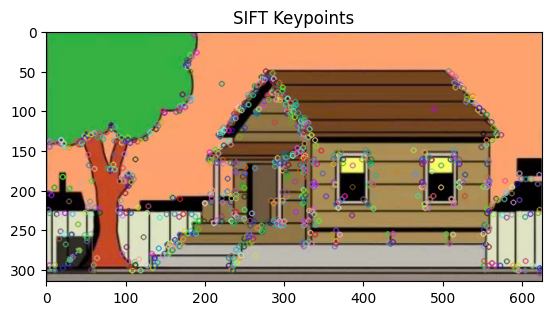

In [6]:
#6. Kiểm tra ảnh qua Scale-space blob detector
img = cv2.imread('example.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp,des = sift.detectAndCompute(gray,None)

img_kp = cv2.drawKeypoints(img,kp,None)

plt.imshow(img_kp[:,:,::-1])
plt.title("SIFT Keypoints")
plt.show()

## 7. Thực hành với Bag-of-words detection

In [7]:
#7. Thực hành với Bag-of-words detection
sift = cv2.SIFT_create()

img = cv2.imread('example.jpg',0)

kp,des = sift.detectAndCompute(img,None)

bow_trainer = cv2.BOWKMeansTrainer(50)

bow_trainer.add(des)

vocab = bow_trainer.cluster()

print("Vocabulary shape:", vocab.shape)

Vocabulary shape: (50, 128)


## 8. Ghép ảnh Image Panoramas

In [9]:
#8. Ghép ảnh Image Panoramas
img1 = cv2.imread('example.jpg')
img2 = cv2.imread('baboon.png')

stitcher = cv2.Stitcher_create()

status, pano = stitcher.stitch([img1,img2])

if status == cv2.Stitcher_OK:
    plt.imshow(pano[:,:,::-1])
    plt.title("Panorama")
    plt.show()
else:
    print("Stitching failed")

Stitching failed


## 9. Ghép ảnh Automatic mosaicing

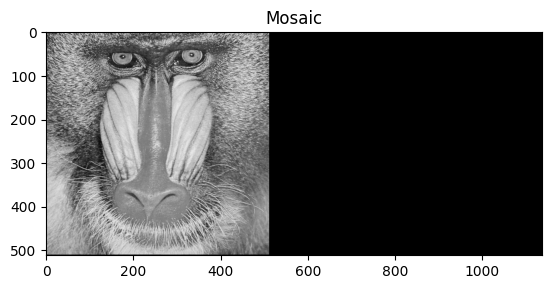

In [10]:
#9. Ghép ảnh Automatic mosaicing
img1 = cv2.imread('example.jpg',0)
img2 = cv2.imread('baboon.png',0)

sift = cv2.SIFT_create()

kp1,des1 = sift.detectAndCompute(img1,None)
kp2,des2 = sift.detectAndCompute(img2,None)

bf = cv2.BFMatcher()

matches = bf.knnMatch(des1,des2,k=2)

good = []
for m,n in matches:
    if m.distance < 0.75*n.distance:
        good.append(m)

pts1 = np.float32([kp1[m.queryIdx].pt for m in good])
pts2 = np.float32([kp2[m.trainIdx].pt for m in good])

H,_ = cv2.findHomography(pts1,pts2,cv2.RANSAC)

result = cv2.warpPerspective(img1,H,(img2.shape[1]+img1.shape[1],img2.shape[0]))
result[0:img2.shape[0],0:img2.shape[1]] = img2

plt.imshow(result,cmap='gray')
plt.title("Mosaic")
plt.show()

## 10. Sử dụng Wide base-line stereo

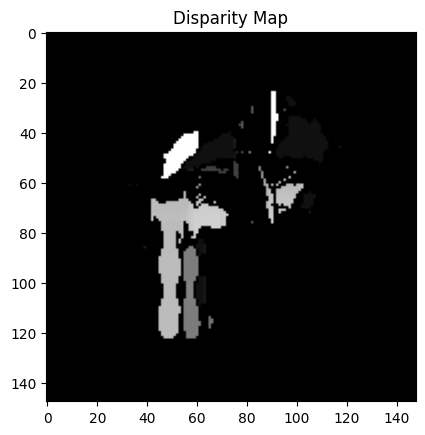

In [12]:
#10. Sử dụng Wide base-line stereo
imgL = cv2.imread('left.png',0)
imgR = cv2.imread('right.png',0)

# Resize imgR to match imgL's size for stereo computation
imgR = cv2.resize(imgR, (imgL.shape[1], imgL.shape[0]))

stereo = cv2.StereoBM_create(numDisparities=16, blockSize=15)

disparity = stereo.compute(imgL,imgR)

plt.imshow(disparity,cmap='gray')
plt.title("Disparity Map")
plt.show()

## 11. CBIR (content-based image retrieval)

In [20]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Danh sách ảnh trong database
images = ['example.jpg','example2.jpg','example3.jpg','example4.jpg']

# Ảnh truy vấn
query = cv2.imread('example.jpg')

# Tính histogram cho ảnh query
query_hist = cv2.calcHist([query],[0,1,2],None,[8,8,8],[0,256,0,256,0,256])
query_hist = cv2.normalize(query_hist,query_hist).flatten()

results = []

for img_path in images:

    img = cv2.imread(img_path)
    if img is None:
        continue

    hist = cv2.calcHist([img],[0,1,2],None,[8,8,8],[0,256,0,256,0,256])
    hist = cv2.normalize(hist,hist).flatten()

    # So sánh histogram
    score = cv2.compareHist(query_hist, hist, cv2.HISTCMP_CORREL)

    results.append((score,img_path))

# Sắp xếp kết quả
results = sorted(results, reverse=True)

print("CBIR results:")
for score,path in results:
    print(path,score)

CBIR results:
example.jpg 1.0


In [23]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans

# Danh sách ảnh database
image_paths = ['example.jpg','example2.jpg','example3.jpg','example4.jpg']

# Khởi tạo SIFT
sift = cv2.SIFT_create()

descriptor_list = []

# 1. Trích xuất SIFT descriptors
for path in image_paths:
    img = cv2.imread(path,0)
    if img is None:
        continue
    kp, des = sift.detectAndCompute(img,None)
    
    if des is not None:
        descriptor_list.extend(des)

descriptor_list = np.array(descriptor_list)

# 2. K-means clustering để tạo visual words
k = 40
kmeans = KMeans(n_clusters=k)
kmeans.fit(descriptor_list)
# 3. Tạo histogram cho từng ảnh
histograms = []

for path in image_paths:
    
    img = cv2.imread(path,0)
    if img is None:
        hist = np.zeros(k)
        histograms.append(hist)
        continue
    kp, des = sift.detectAndCompute(img,None)
    
    hist = np.zeros(k)
    
    if des is not None:
        labels = kmeans.predict(des)
        
        for l in labels:
            hist[l] += 1
    
    histograms.append(hist)

histograms = np.array(histograms)

print("Histogram representation of images:")
print(histograms)

Histogram representation of images:
[[14. 18.  9. 23. 25. 24. 23. 60. 24. 39. 39. 40. 15. 12. 16. 39. 27. 15.
  12. 31. 18. 16. 25. 13. 29. 14. 12. 15. 11. 12. 44. 48.  7. 18. 10. 10.
  37. 28. 34. 24.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.]]
